In [24]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf

df = pd.read_csv("/Users/michalmetel/Desktop/data/dataset.csv", sep=";")
for col in df.columns:
    df[col] = df[col].astype(str).str.replace(",", ".")
    df[col] = pd.to_numeric(df[col], errors="coerce")

df["logC"] = np.log10(df["AgNPs"] + 1e-6)
df.drop(columns=["AgNPs"], inplace=True)
df.dropna(inplace=True)
df

,Incubation [h],Viability [%],Drug,logC
0,48.0,74.15,0.00,1.397940e+00
1,48.0,73.62,0.00,1.698970e+00
2,48.0,65.57,0.00,2.000000e+00
3,48.0,25.25,0.00,2.301030e+00
4,24.0,92.00,0.00,-2.568475e+00
5,24.0,72.00,0.00,-2.267526e+00
6,24.0,50.00,0.00,-1.966536e+00
7,24.0,20.00,0.00,-1.790458e+00
8,24.0,7.00,0.00,-1.665526e+00
9,24.0,84.00,0.00,4.342943e-07


In [37]:
import statsmodels.formula.api as smf

m1 = smf.ols(
    "Q('Viability [%]') ~ logC * Q('Incubation [h]') + Drug",
    data=df
).fit()

m1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:     Q('Viability [%]')   R-squared:                       0.357
Model:                            OLS   Adj. R-squared:                  0.300
Method:                 Least Squares   F-statistic:                     6.243
Date:                Sun, 04 Jan 2026   Prob (F-statistic):           0.000439
Time:                        23:05:54   Log-Likelihood:                -230.86
No. Observations:                  50   AIC:                             471.7
Df Residuals:                      45   BIC:                             481.3
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
============================================================================================
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept                   50.9757      9.907      5.145      0.000      31.021      70.930
logC                       -11.1418      6.359     -1.752      0.087     -23.950       1.667
Q('Incubation [h]')          0.2047      0.323      0.634      0.529      -0.445       0.854
logC:Q('Incubation [h]')     0.1096      0.224      0.490      0.626      -0.341       0.560
Drug                       -11.5398      4.289     -2.690      0.010     -20.179      -2.900
==============================================================================
Omnibus:                        1.228   Durbin-Watson:                   1.061
Prob(Omnibus):                  0.541   Jarque-Bera (JB):                1.234
Skew:                          -0.284   Prob(JB):                        0.540
Kurtosis:                       2.480   Cond. No.                         183.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [38]:
m1.aic, m1.bic

(np.float64(471.71246802988003), np.float64(481.27258305702077))

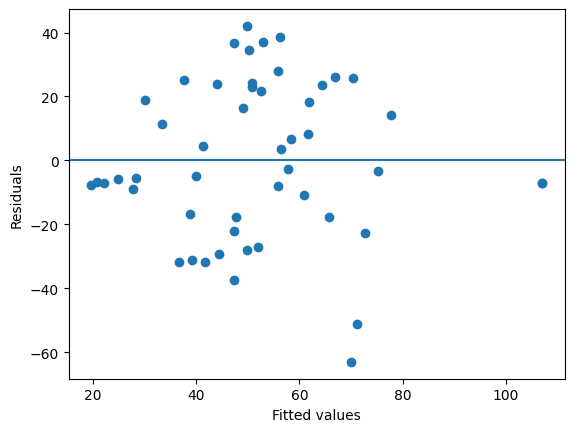

In [39]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(m1.fittedvalues, m1.resid)
plt.axhline(0)
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.show()


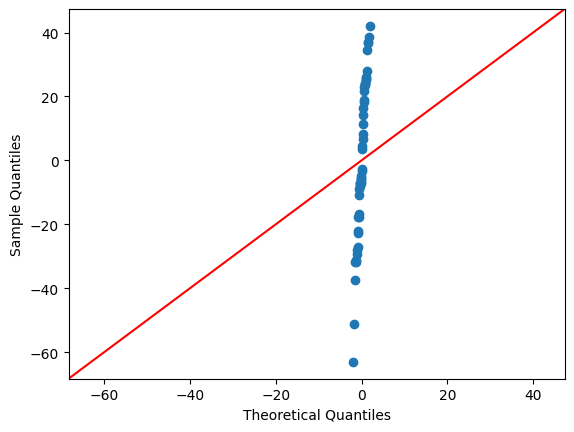

In [40]:
import statsmodels.api as sm

sm.qqplot(m1.resid, line="45")
plt.show()


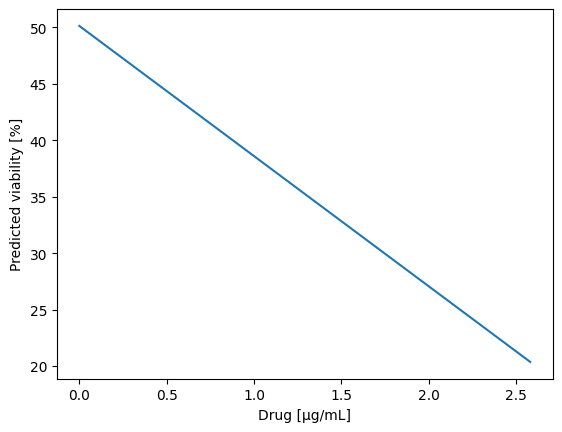

In [41]:
import pandas as pd
import numpy as np

drug_range = np.linspace(0, df["Drug"].max(), 50)

pred_df = pd.DataFrame({
    "Drug": drug_range,
    "logC": df["logC"].median(),
    "Incubation [h]": df["Incubation [h]"].median()
})

pred_df["Viability_pred"] = m1.predict(pred_df)

plt.figure()
plt.plot(drug_range, pred_df["Viability_pred"])
plt.xlabel("Drug [µg/mL]")
plt.ylabel("Predicted viability [%]")
plt.show()


################## TESTOWE ####################

In [28]:
import statsmodels.formula.api as smf

model = smf.ols(
    "Q('Viability [%]') ~ logC * Q('Incubation [h]') + Drug",
    data=df
).fit()

model_int = smf.ols(
    "Q('Viability [%]') ~ logC * Q('Incubation [h]') + Drug + logC:Drug",
    data=df
).fit()

model.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:     Q('Viability [%]')   R-squared:                       0.357
Model:                            OLS   Adj. R-squared:                  0.300
Method:                 Least Squares   F-statistic:                     6.243
Date:                Sun, 04 Jan 2026   Prob (F-statistic):           0.000439
Time:                        23:00:52   Log-Likelihood:                -230.86
No. Observations:                  50   AIC:                             471.7
Df Residuals:                      45   BIC:                             481.3
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
============================================================================================
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept                   50.9757      9.907      5.145      0.000      31.021      70.930
logC                       -11.1418      6.359     -1.752      0.087     -23.950       1.667
Q('Incubation [h]')          0.2047      0.323      0.634      0.529      -0.445       0.854
logC:Q('Incubation [h]')     0.1096      0.224      0.490      0.626      -0.341       0.560
Drug                       -11.5398      4.289     -2.690      0.010     -20.179      -2.900
==============================================================================
Omnibus:                        1.228   Durbin-Watson:                   1.061
Prob(Omnibus):                  0.541   Jarque-Bera (JB):                1.234
Skew:                          -0.284   Prob(JB):                        0.540
Kurtosis:                       2.480   Cond. No.                         183.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [33]:
# Model bazowy (bez leku)
m0 = smf.ols(
    "Q('Viability [%]') ~ logC * Q('Incubation [h]')",
    data=df
).fit()

# Model z lekiem (liniowo)
m1 = smf.ols(
    "Q('Viability [%]') ~ logC * Q('Incubation [h]') + Drug",
    data=df
).fit()

# Model z interakcją AgNPs × lek
m2 = smf.ols(
    "Q('Viability [%]') ~ logC * Q('Incubation [h]') + Drug + logC:Drug",
    data=df
).fit()

for name, m in zip(["m0", "m1", "m2"], [m0, m1, m2]):
    print(name, "AIC:", m.aic, "BIC:", m.bic)


m0 AIC: 477.169434039952 BIC: 484.8175260616646
m1 AIC: 471.71246802988003 BIC: 481.27258305702077
m2 AIC: 472.0131498180164 BIC: 483.4852878505853


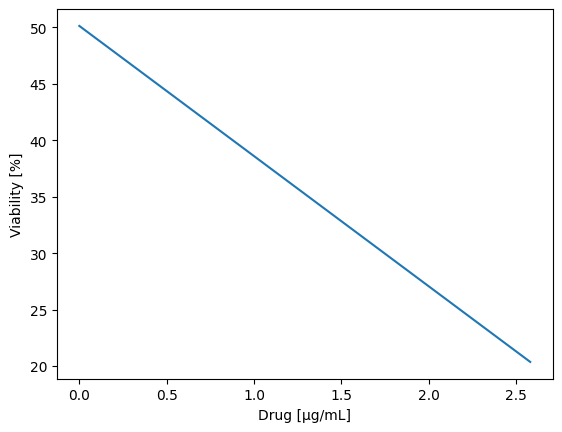

In [35]:
import matplotlib.pyplot as plt
import numpy as np

drug_range = np.linspace(0, df["Drug"].max(), 50)
pred_df = pd.DataFrame({
    "Drug": drug_range,
    "logC": df["logC"].median(),
    "Incubation [h]": df["Incubation [h]"].median()
})

pred_df["pred"] = m1.predict(pred_df)

plt.figure()
plt.plot(drug_range, pred_df["pred"])
plt.xlabel("Drug [µg/mL]")
plt.ylabel("Viability [%]")
plt.show()


In [ ]:
import statsmodels.graphics.api as smg

smg.interaction_plot(
    df["logC"],
    df["Incubation [h]"],
    df["Viability [%]"]
)
plt.show()


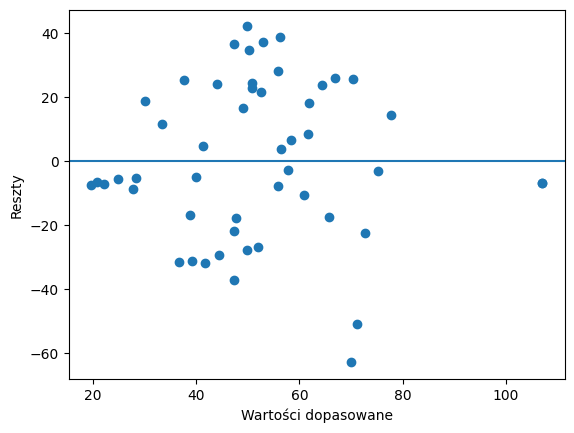

In [31]:
import matplotlib.pyplot as plt

residuals = model.resid
fitted = model.fittedvalues

plt.scatter(fitted, residuals)
plt.axhline(0)
plt.xlabel("Wartości dopasowane")
plt.ylabel("Reszty")
plt.show()
